# qiu_2026 — inspect trained-model predictions vs. recordings

Loads a trained `core_readout` checkpoint and compares its predicted neural responses against the
recorded responses, on held-out (validation/test) clips, **with the pupil shifter active**.

**How to use**
1. Set `SESSION` / `SPLIT` / `CKPT_PATH` in the config cell (defaults auto-pick the newest checkpoint).
2. Run all cells.

**Notes**
- Scoped to **one session** on purpose — loading all 10 would exceed the notebook kernel's memory.
  Change `SESSION` to any of the 10 (they all have readout heads in the trained model).
- Works on a *mid-training* checkpoint too — re-run after the job saves a newer/better one.
- The causal core trims the first `lag = T_in - T_out` frames; predictions are aligned to the
  recorded trace by dropping those leading frames from the target.


In [1]:
import os
from pathlib import Path

import hydra
import numpy as np
import torch
import matplotlib.pyplot as plt
from hydra import compose, initialize_config_dir

from openretina.utils.file_utils import get_cache_directory
from openretina.models.core_readout import load_core_readout_model

# ---- config: edit these ----
REPO = Path("/weka/bethge/bkr578/projects/open-retina")
SESSION = "dynamic28188-16-3-Fluorescence-7b721b-v4a"  # single session to inspect
SPLIT = "validation"   # "validation", "train", or a test-condition name (listed a few cells down)
CKPT_PATH = None       # None -> auto-pick newest checkpoint under the latest run
# ----------------------------

os.environ.setdefault("OPENRETINA_CACHE_DIRECTORY", str(get_cache_directory()))
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| cache:", os.environ["OPENRETINA_CACHE_DIRECTORY"])

device: cuda | cache: /home/bethge/bkr578/openretina_cache


In [2]:
# Locate the checkpoint (newest .ckpt across all runs, unless CKPT_PATH is set)
if CKPT_PATH is None:
    ckpts = sorted(
        (REPO / "openretina_assets/runs/core_readout_qiu_2026_mouse").glob("*/checkpoints/*.ckpt"),
        key=lambda p: p.stat().st_mtime,
    )
    assert ckpts, "No checkpoint found yet - wait for the training job to finish epoch 0."
    CKPT_PATH = ckpts[-1]
CKPT_PATH = Path(CKPT_PATH)
print("Using checkpoint:", CKPT_PATH.name)
print("  full path:", CKPT_PATH)

Using checkpoint: epoch=49_val_evaluation_loss=0.402_final.ckpt
  full path: /weka/bethge/bkr578/projects/open-retina/openretina_assets/runs/core_readout_qiu_2026_mouse/2026-07-23_14-52-28/checkpoints/epoch=49_val_evaluation_loss=0.402_final.ckpt


In [3]:
# Load the trained model (rebuilds core + readout + shifter from the checkpoint's hparams)
model = load_core_readout_model(str(CKPT_PATH), device)
model.eval()
readout_sessions = list(model.readout.keys())
print(f"{len(readout_sessions)} readout heads; shifter present: {getattr(model, 'shifter', None) is not None}")
assert SESSION in readout_sessions, f"{SESSION!r} not among trained sessions: {readout_sessions}" 

10 readout heads; shifter present: True


In [4]:
model

UnifiedCoreReadout(
  (core): <super: <class 'Core'>, <SimpleCoreWrapper object>> [SimpleCoreWrapper regularizers: gamma_hidden = 0.0|gamma_in_sparse = 0.0|gamma_input = 10|gamma_temporal = 0.01]
  
  (readout): MultiSampledGaussianReadout(
    (dynamic28188-16-3-Fluorescence-7b721b-v4a): full PointGaussianReadout (64 x 18 x 46 -> 2710) with bias
    (dynamic28188-16-5-Fluorescence-7b721b-v4a): full PointGaussianReadout (64 x 18 x 46 -> 2046) with bias
    (dynamic28188-17-2-Fluorescence-7b721b-v4a): full PointGaussianReadout (64 x 18 x 46 -> 1714) with bias
    (dynamic28188-18-4-Fluorescence-7b721b-v4a): full PointGaussianReadout (64 x 18 x 46 -> 1593) with bias
    (dynamic28188-19-9-Fluorescence-7b721b-v4a): full PointGaussianReadout (64 x 18 x 46 -> 787) with bias
    (dynamic28712-3-8-Fluorescence-7b721b-v4a): full PointGaussianReadout (64 x 18 x 46 -> 1728) with bias
    (dynamic29163-2-7-Fluorescence-7b721b-v4a): full PointGaussianReadout (64 x 18 x 46 -> 1327) with bias
    (d

In [5]:
# Build dataloaders for the single chosen session (compose the training config, filter sessions)
with initialize_config_dir(config_dir=str(REPO / "configs"), version_base="1.3"):
    cfg = compose(
        config_name="qiu_2026_core_readout",
        overrides=[
            f"+data_io.stimuli.sessions=[{SESSION}]",
            f"+data_io.responses.sessions=[{SESSION}]",
            f"+data_io.pupil.sessions=[{SESSION}]",
            "dataloader.batch_size=8",
        ],
    )

movies = hydra.utils.call(cfg.data_io.stimuli)
responses = hydra.utils.call(cfg.data_io.responses)
pupil = hydra.utils.call(cfg.data_io.pupil)
dataloaders = hydra.utils.instantiate(
    cfg.dataloader,
    neuron_data_dictionary=responses,
    movies_dictionary=movies,
    pupil_dictionary=pupil,
)

splits = list(dataloaders.keys())
test_conditions = [s for s in splits if s not in ("train", "validation")]
print("splits:", ["train", "validation"], f"+ {len(test_conditions)} test-condition keys")
print("example test-condition keys:", test_conditions[:5])
assert SPLIT in dataloaders, f"SPLIT={SPLIT!r} not available. Choose from train/validation or a test key above."


qiu_2026 stimuli:   0%|          | 0/1 [00:00<?, ?it/s]

qiu_2026 responses:   0%|          | 0/1 [00:00<?, ?it/s]

qiu_2026 pupil:   0%|          | 0/1 [00:00<?, ?it/s]

Creating qiu movie dataloaders:   0%|          | 0/1 [00:00<?, ?it/s]

splits: ['train', 'validation'] + 95 test-condition keys
example test-condition keys: ['ubOIjeUGbsNAJqMPIDqU', 'ihsP/Q14/eSpxdQLR3F4', 'aedxogPGpb5IiLcjLo8c', '3wXTReOQa7mnr6Oz8aUf', '0eP/PPhAGmbJ2peZOa/E']


In [6]:
# Run the model over the chosen split, WITH the pupil shifter, and align to the recorded trace
dl = dataloaders[SPLIT][SESSION]
preds, targs = [], []
run_speed, pupil_size, pupil_pos = [], [], []  # behavior covariates, aligned to the output frames
lag = None
with torch.no_grad():
    for batch in dl:
        inputs = batch.inputs.to(device)               # (B, 3, T, H, W)
        pupil_center = batch.pupil_center.to(device)   # (B, 2, T)
        out = model.forward(inputs, data_key=SESSION, pupil_center=pupil_center)  # (B, T_out, N)
        targets = batch.targets                        # (B, T, N)
        lag = targets.shape[1] - out.shape[1]          # frames trimmed by the causal core
        targets = targets[:, lag:, :]
        preds.append(out.cpu().numpy().reshape(-1, out.shape[-1]))
        targs.append(targets.cpu().numpy().reshape(-1, targets.shape[-1]))
        # Behavior the model actually saw, trimmed to the output frames and flattened like the traces.
        # Input channels: 1 = pupil size, 2 = running speed (broadcast over pixels -> take any pixel).
        pupil_size.append(batch.inputs[:, 1, lag:, 0, 0].cpu().numpy().reshape(-1))
        run_speed.append(batch.inputs[:, 2, lag:, 0, 0].cpu().numpy().reshape(-1))
        # pupil_center (B, 2, T) = eye position (x, y) -> shifter input.
        pupil_pos.append(batch.pupil_center[:, :, lag:].cpu().numpy().transpose(0, 2, 1).reshape(-1, 2))

pred = np.concatenate(preds)             # (time, neurons)
targ = np.concatenate(targs)             # (time, neurons)
run_speed = np.concatenate(run_speed)    # (time,)
pupil_size = np.concatenate(pupil_size)  # (time,)
pupil_pos = np.concatenate(pupil_pos)    # (time, 2): columns = pupil x, pupil y
print(f"predicted {pred.shape}, recorded {targ.shape}, lag={lag} frames")
print(f"behavior aligned: run_speed {run_speed.shape}, pupil_size {pupil_size.shape}, pupil_pos {pupil_pos.shape}")

predicted (7896, 2710), recorded (7896, 2710), lag=18 frames
behavior aligned: run_speed (7896,), pupil_size (7896,), pupil_pos (7896, 2)


correlation  mean=0.554  median=0.548  max=0.862  n_neurons=2710


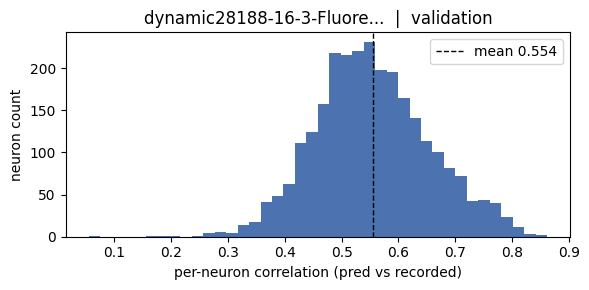

In [7]:
# Per-neuron correlation between prediction and recording
def per_neuron_corr(a, b, eps=1e-8):
    a = a - a.mean(0, keepdims=True)
    b = b - b.mean(0, keepdims=True)
    return (a * b).mean(0) / (a.std(0) * b.std(0) + eps)

c = per_neuron_corr(pred, targ)
print(f"correlation  mean={np.nanmean(c):.3f}  median={np.nanmedian(c):.3f}  "
      f"max={np.nanmax(c):.3f}  n_neurons={len(c)}")

plt.figure(figsize=(6, 3))
plt.hist(c[~np.isnan(c)], bins=40, color="#4c72b0")
plt.axvline(np.nanmean(c), color="k", ls="--", lw=1, label=f"mean {np.nanmean(c):.3f}")
plt.xlabel("per-neuron correlation (pred vs recorded)")
plt.ylabel("neuron count")
plt.title(f"{SESSION[:24]}...  |  {SPLIT}")
plt.legend()
plt.tight_layout()
plt.show()

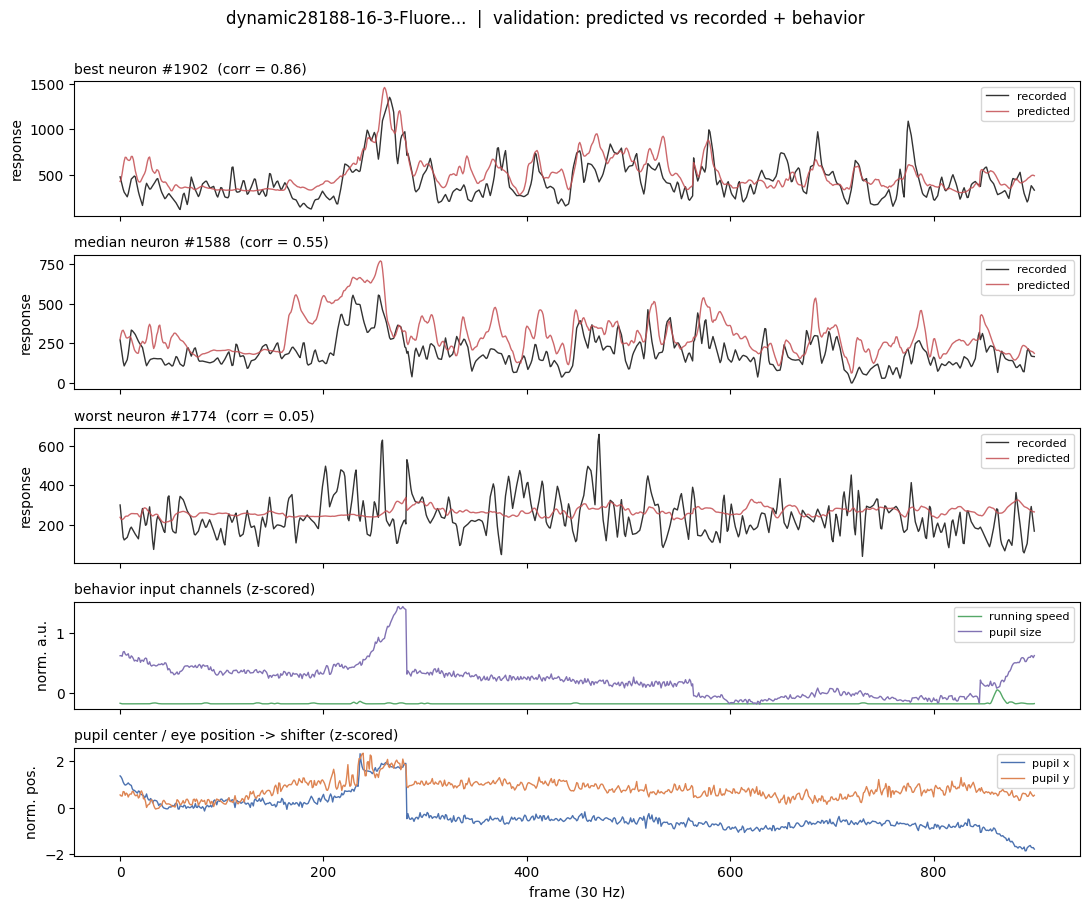

In [8]:
# Example traces: best / median / worst neurons by correlation, with the behavior covariates below.
order = np.argsort(np.nan_to_num(c, nan=-np.inf))
picks = {"best": order[-1], "median": order[len(order) // 2], "worst": order[0]}
T = min(900, pred.shape[0])  # ~30 s at 30 Hz

n_rows = len(picks) + 2  # 3 neuron traces + behavior (speed/size) + pupil position
fig, axs = plt.subplots(
    n_rows, 1, figsize=(11, 9), sharex=True,
    gridspec_kw={"height_ratios": [1] * len(picks) + [0.8, 0.8]},
)

for ax, (label, n) in zip(axs, picks.items()):
    ax.plot(targ[:T, n], lw=1.0, label="recorded", color="#333333")
    ax.plot(pred[:T, n], lw=1.0, alpha=0.85, label="predicted", color="#c44e52")
    ax.set_title(f"{label} neuron #{n}  (corr = {c[n]:.2f})", fontsize=10, loc="left")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_ylabel("response")

# Behavior input channels the model saw (z-scored): running speed + pupil size.
ax_beh = axs[len(picks)]
ax_beh.plot(run_speed[:T], lw=1.0, color="#55a868", label="running speed")
ax_beh.plot(pupil_size[:T], lw=1.0, color="#8172b3", label="pupil size")
ax_beh.set_title("behavior input channels (z-scored)", fontsize=10, loc="left")
ax_beh.legend(loc="upper right", fontsize=8)
ax_beh.set_ylabel("norm. a.u.")

# Pupil center / eye position (the shifter input), z-scored.
ax_pos = axs[len(picks) + 1]
ax_pos.plot(pupil_pos[:T, 0], lw=1.0, color="#4c72b0", label="pupil x")
ax_pos.plot(pupil_pos[:T, 1], lw=1.0, color="#dd8452", label="pupil y")
ax_pos.set_title("pupil center / eye position -> shifter (z-scored)", fontsize=10, loc="left")
ax_pos.legend(loc="upper right", fontsize=8)
ax_pos.set_ylabel("norm. pos.")

axs[-1].set_xlabel("frame (30 Hz)")
fig.suptitle(f"{SESSION[:24]}...  |  {SPLIT}: predicted vs recorded + behavior", y=1.005)
plt.tight_layout()
plt.show()

## Where to go next
- **Change `SPLIT`** to one of the printed test-condition keys to inspect a specific held-out clip
  (test clips are evaluated as whole 300/450-frame clips).
- **Compare across sessions**: rerun with a different `SESSION` (memory-safe, one at a time).
- **Oracle / FEVE**: the repeated "oracle" test clips have multiple repeats, enabling explainable-variance
  metrics (`openretina.eval.metrics.feve`, `openretina.eval.oracles.oracle_corr_jackknife`) — see
  `openretina/cli/eval.py` for the full metric suite.
- **Sanity on the shifter**: rerun the prediction cell passing `pupil_center=None` to `model.forward`
  and compare correlations to see how much the pupil shifter contributes.
